# Customer Cohort, RFM & Churn Analysis
**Prepared by:** Jasline Mwita  
**Dataset:** Olist Brazilian E-Commerce (2016–2018)  
**Business question:** *Who are our most valuable customers, which cohorts retained best, and can we predict which new customers will churn?*

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

PROCESSED = Path('../data/processed')

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style('whitegrid')

master           = pd.read_csv(PROCESSED / 'master_orders.csv', parse_dates=['order_purchase_timestamp'])
customer_summary = pd.read_csv(PROCESSED / 'customer_summary.csv', parse_dates=['first_purchase', 'last_purchase'])

print(f'Orders loaded:    {len(master):,}')
print(f'Customers loaded: {len(customer_summary):,}')

Orders loaded:    96,478
Customers loaded: 93,358


---
## Part 1 — Cohort Retention Analysis

**What this tells us:** By grouping customers by the month they first purchased, we can track what percentage of each cohort returned in subsequent months. A healthy retention curve flattens above 10–15%; our platform's curve will show us the true scale of the churn problem.

> **Analyst note:** Cohort analysis is more honest than overall retention rate — it controls for the growth effect (a platform with more new customers looks like it has lower retention even if nothing changed).

In [2]:
# Assign each customer their cohort (month of first purchase)
first_purchase = (
    master.groupby('customer_unique_id')['order_purchase_timestamp']
    .min()
    .dt.to_period('M')
    .rename('cohort_month')
    .reset_index()
)

# Add activity month to each order
master['activity_month'] = master['order_purchase_timestamp'].dt.to_period('M')

# Merge cohort month into orders
cohort_df = master.merge(first_purchase, on='customer_unique_id', how='left')

# Period number: how many months after first purchase?
cohort_df['period_number'] = (
    cohort_df['activity_month'].dt.to_timestamp() -
    cohort_df['cohort_month'].dt.to_timestamp()
).dt.days // 30

# Count unique active customers per cohort per period
cohort_counts = (
    cohort_df.groupby(['cohort_month', 'period_number'])['customer_unique_id']
    .nunique()
    .reset_index(name='customers')
)

# Pivot into matrix
cohort_pivot = cohort_counts.pivot_table(
    index='cohort_month', columns='period_number', values='customers'
)

# Retention %: divide every period by period 0 (cohort size)
cohort_size   = cohort_pivot[0]
retention_pct = cohort_pivot.divide(cohort_size, axis=0).round(3)

print('Cohort matrix built.')
print(f'Cohorts: {len(retention_pct)} months | Periods tracked: {len(retention_pct.columns)}')

Cohort matrix built.
Cohorts: 23 months | Periods tracked: 20


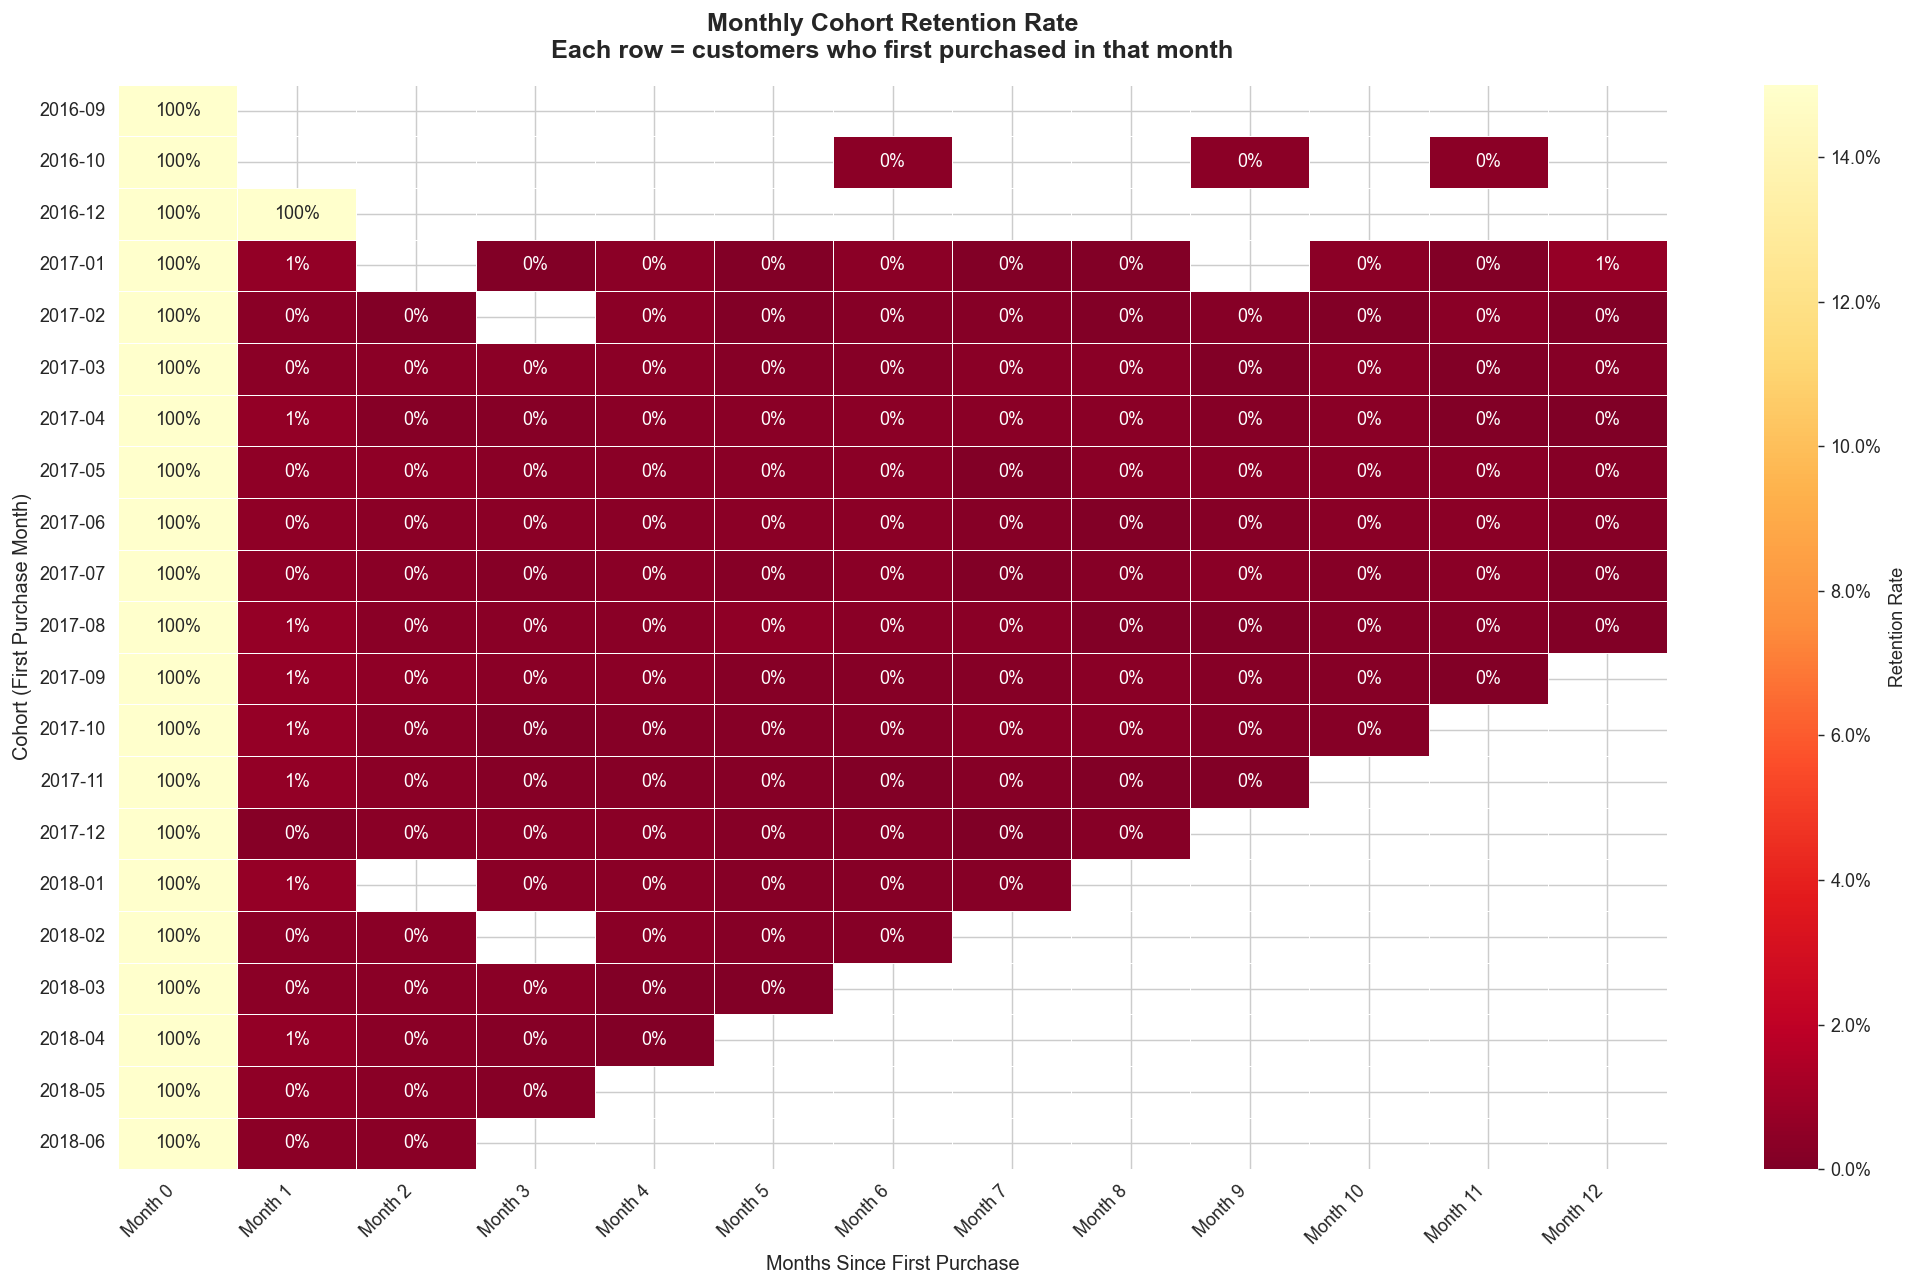

Chart saved.


In [3]:
# Plot cohort retention heatmap — the centrepiece visual of this project
fig, ax = plt.subplots(figsize=(16, 10))

# Limit to first 13 periods and cohorts with enough data
plot_data = retention_pct.iloc[:-2, :13]  # drop last 2 cohorts (incomplete)

sns.heatmap(
    plot_data,
    annot=True,
    fmt='.0%',
    cmap='YlOrRd_r',
    vmin=0, vmax=0.15,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Retention Rate', 'format': mtick.PercentFormatter(xmax=1)}
)

ax.set_title('Monthly Cohort Retention Rate\nEach row = customers who first purchased in that month', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Months Since First Purchase', fontsize=11)
ax.set_ylabel('Cohort (First Purchase Month)', fontsize=11)
ax.set_xticklabels([f'Month {i}' for i in range(13)], rotation=45, ha='right')
ax.set_yticklabels([str(p) for p in plot_data.index], rotation=0)

plt.tight_layout()
plt.savefig('../data/processed/cohort_heatmap.png', bbox_inches='tight')
plt.show()
print('Chart saved.')

In [4]:
# Key cohort insight: average retention by period
avg_retention = plot_data.mean()
print('=== Average Retention Across All Cohorts ===')
for period, rate in avg_retention.items():
    bar = '█' * int(rate * 200)
    print(f'  Month {period:>2}: {rate:.1%}  {bar}')

print(f"\n>>> After Month 1, average retention drops to {avg_retention[1]:.1%}")
print(f">>> By Month 3, it stabilises around {avg_retention.iloc[3:6].mean():.1%}")
print(">>> Implication: the first 30 days are the critical retention window.")

=== Average Retention Across All Cohorts ===
  Month  0: 100.0%  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  Month  1: 5.8%  ███████████
  Month  2: 0.3%  
  Month  3: 0.3%  
  Month  4: 0.3%  
  Month  5: 0.2%  
  Month  6: 0.3%  
  Month  7: 0.2%  
  Month  8: 0.2%  
  Month  9: 0.2%  
  Month 10: 0.3%  
  Month 11: 0.2%  
  Month 12: 0.2%  

>>> After Month 1, average retention drops to 5.8%
>>> By Month 3, it stabilises around 0.3%
>>> Implication: the first 30 days are the critical retention window.


---
## Part 2 — RFM Segmentation

**What this tells us:** RFM (Recency, Frequency, Monetary) is the gold standard for customer segmentation in e-commerce. It answers: *who bought recently, who buys often, and who spends the most?* Combining these three dimensions lets us label customers as Champions, Loyal, At Risk, or Churned — and target them differently.

| Dimension | Definition |
|-----------|------------|
| **Recency** | Days since last purchase (lower = better) |
| **Frequency** | Number of orders placed |
| **Monetary** | Total amount spent (R$) |

In [5]:
# Reference date = 1 day after the last order in the dataset
reference_date = master['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print(f'Reference date: {reference_date.date()}')

rfm = master.groupby('customer_unique_id').agg(
    recency=('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
    frequency=('order_id', 'count'),
    monetary=('total_order_value', 'sum')
).reset_index()

print(f'\nRFM table: {len(rfm):,} customers')
print(rfm[['recency', 'frequency', 'monetary']].describe().round(1))

Reference date: 2018-08-30



RFM table: 93,358 customers
       recency  frequency  monetary
count  93358.0    93358.0   93358.0
mean     237.9        1.0     165.2
std      152.6        0.2     226.3
min        1.0        1.0       9.6
25%      114.0        1.0      63.0
50%      219.0        1.0     107.8
75%      346.0        1.0     182.5
max      714.0       15.0   13664.1


In [6]:
# Score each dimension 1-5 (5 = best)
# Recency: lower days = better = higher score, so we reverse it
rfm['r_score'] = pd.qcut(rfm['recency'],   q=5, labels=[5,4,3,2,1]).astype(int)
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)
rfm['m_score'] = pd.qcut(rfm['monetary'],  q=5, labels=[1,2,3,4,5]).astype(int)

rfm['rfm_score'] = rfm['r_score'].astype(str) + rfm['f_score'].astype(str) + rfm['m_score'].astype(str)
rfm['total_score'] = rfm['r_score'] + rfm['f_score'] + rfm['m_score']

print('Scores assigned. Sample:')
print(rfm[['customer_unique_id','recency','frequency','monetary','r_score','f_score','m_score','total_score']].head(8).to_string(index=False))

Scores assigned. Sample:
              customer_unique_id  recency  frequency  monetary  r_score  f_score  m_score  total_score
0000366f3b9a7992bf8c76cfdf3221e2      112          1    141.90        4        1        4            9
0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     27.19        4        1        1            6
0000f46a3911fa3c0805444483337064      537          1     86.22        1        1        2            4
0000f6ccb0745a6a4b88665a16c9f078      321          1     43.62        2        1        1            4
0004aac84e0df4da2b147fca70cf8255      288          1    196.89        2        1        4            7
0004bd2a26a76fe21f786e4fbd80607f      146          1    166.98        4        1        4            9
00050ab1314c0e55a6ca13cf7181fecf      132          1     35.38        4        1        1            6
00053a61a98854899e70ed204dd4bafe      183          1    419.18        3        1        5            9


In [7]:
# Assign business segment labels based on scores
def assign_segment(row):
    r, f, m = row['r_score'], row['f_score'], row['m_score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champion'
    elif r >= 3 and f >= 3:
        return 'Loyal'
    elif r >= 4 and f <= 2:
        return 'New Customer'
    elif r >= 3 and f <= 2 and m >= 3:
        return 'Potential Loyalist'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m >= 3:
        return 'Cannot Lose Them'
    elif r <= 2:
        return 'Churned'
    else:
        return 'Needs Attention'

rfm['segment'] = rfm.apply(assign_segment, axis=1)

seg_summary = rfm.groupby('segment').agg(
    customer_count=('customer_unique_id', 'count'),
    avg_monetary=('monetary', 'mean'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean')
).sort_values('avg_monetary', ascending=False).round(1)

seg_summary['revenue_share'] = (
    rfm.groupby('segment')['monetary'].sum() / rfm['monetary'].sum() * 100
).round(1)

print('=== RFM Segment Summary ===')
print(seg_summary.to_string())

=== RFM Segment Summary ===
                    customer_count  avg_monetary  avg_recency  avg_frequency  revenue_share
segment                                                                                    
Champion                      6497         312.0         91.1            1.2           13.1
Cannot Lose Them              8676         240.9        394.5            1.0           13.6
Potential Loyalist            4351         223.1        220.7            1.0            6.3
At Risk                      22230         166.9        394.7            1.0           24.1
New Customer                 14984         163.4         90.9            1.0           15.9
Loyal                        27288         134.0        144.2            1.0           23.7
Churned                       6310          55.8        396.8            1.0            2.3
Needs Attention               3022          54.3        219.6            1.0            1.1


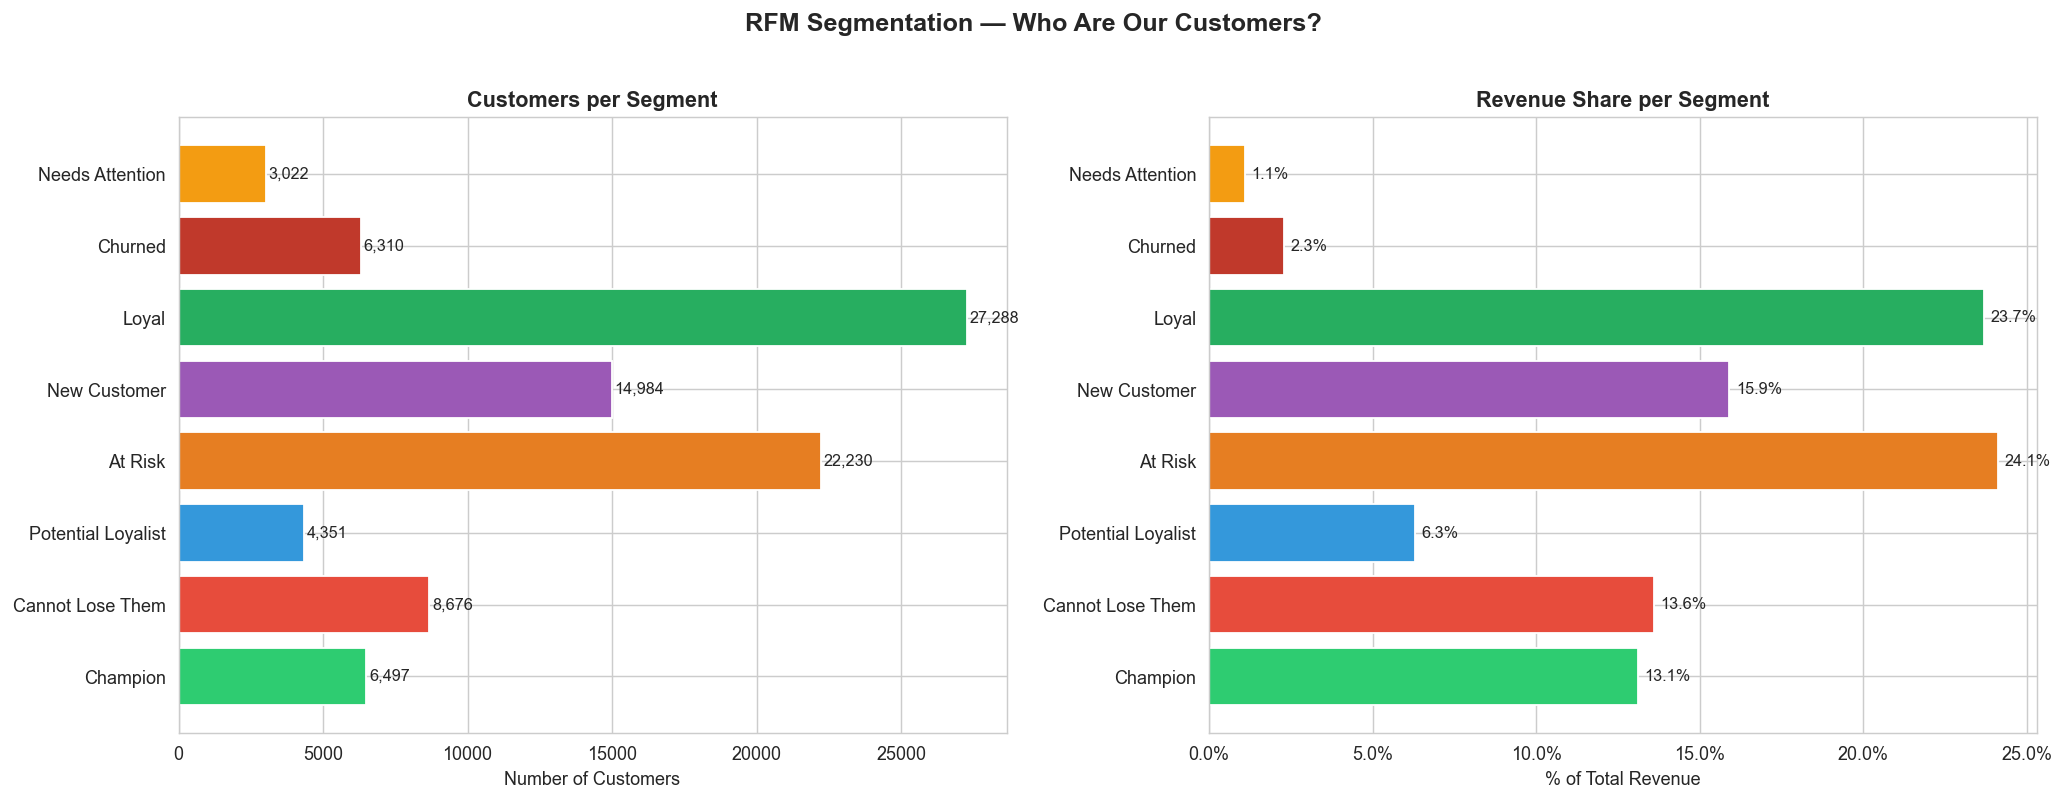

In [8]:
# Visualise 1: Customer count per segment
seg_order = seg_summary.index.tolist()
colors = {
    'Champion': '#2ecc71',
    'Loyal': '#27ae60',
    'Potential Loyalist': '#3498db',
    'New Customer': '#9b59b6',
    'Needs Attention': '#f39c12',
    'At Risk': '#e67e22',
    'Cannot Lose Them': '#e74c3c',
    'Churned': '#c0392b'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: customer count
count_data = rfm['segment'].value_counts().reindex(seg_order).fillna(0)
bar_colors = [colors.get(s, '#95a5a6') for s in count_data.index]
axes[0].barh(count_data.index, count_data.values, color=bar_colors)
axes[0].set_xlabel('Number of Customers')
axes[0].set_title('Customers per Segment', fontweight='bold')
for i, v in enumerate(count_data.values):
    axes[0].text(v + 100, i, f'{v:,.0f}', va='center', fontsize=9)

# Right: revenue share
rev_data = seg_summary['revenue_share'].reindex(seg_order).fillna(0)
axes[1].barh(rev_data.index, rev_data.values, color=bar_colors)
axes[1].set_xlabel('% of Total Revenue')
axes[1].set_title('Revenue Share per Segment', fontweight='bold')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())
for i, v in enumerate(rev_data.values):
    axes[1].text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=9)

plt.suptitle('RFM Segmentation — Who Are Our Customers?', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/rfm_segments.png', bbox_inches='tight')
plt.show()

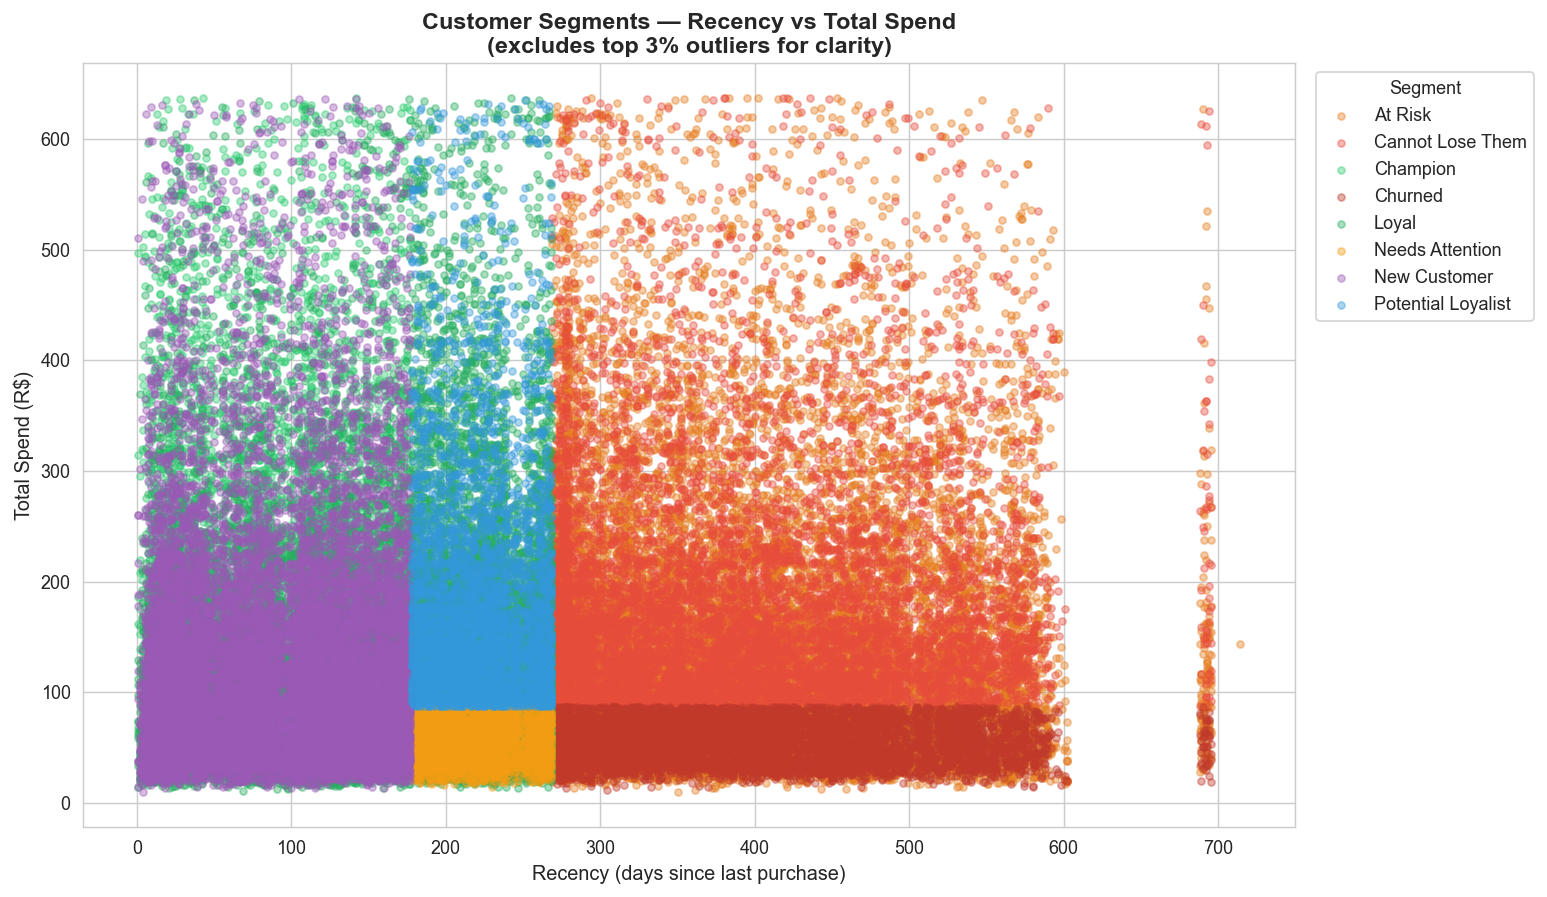

In [9]:
# Visualise 2: Recency vs Monetary scatter coloured by segment
fig, ax = plt.subplots(figsize=(12, 7))

for segment, group in rfm[rfm['monetary'] < rfm['monetary'].quantile(0.97)].groupby('segment'):
    ax.scatter(
        group['recency'], group['monetary'],
        label=segment, alpha=0.4, s=15,
        color=colors.get(segment, '#95a5a6')
    )

ax.set_xlabel('Recency (days since last purchase)', fontsize=11)
ax.set_ylabel('Total Spend (R$)', fontsize=11)
ax.set_title('Customer Segments — Recency vs Total Spend\n(excludes top 3% outliers for clarity)', 
             fontsize=13, fontweight='bold')
ax.legend(title='Segment', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../data/processed/rfm_scatter.png', bbox_inches='tight')
plt.show()

In [10]:
# Export RFM table for Power BI dashboard
rfm.to_csv(PROCESSED / 'rfm_segments.csv', index=False)
print('RFM data exported.')

# Print the key business insight
champ = seg_summary.loc['Champion'] if 'Champion' in seg_summary.index else None
churned = seg_summary.loc['Churned'] if 'Churned' in seg_summary.index else None

if champ is not None:
    print(f"\n>>> Champions: {champ['customer_count']:,.0f} customers ({champ['customer_count']/len(rfm):.1%} of base) drive {champ['revenue_share']:.1f}% of revenue")
if churned is not None:
    print(f">>> Churned:   {churned['customer_count']:,.0f} customers ({churned['customer_count']/len(rfm):.1%} of base) — last seen avg {churned['avg_recency']:.0f} days ago")

RFM data exported.

>>> Champions: 6,497 customers (7.0% of base) drive 13.1% of revenue
>>> Churned:   6,310 customers (6.8% of base) — last seen avg 397 days ago


---
## Part 3 — Churn Prediction Model

**What this tells us:** Instead of just describing who has churned, we want to *predict* which customers are at risk — so retention campaigns can be targeted *before* churn happens.

**Model choice: Random Forest**  
Chosen because it handles non-linear relationships, is robust to outliers, requires minimal preprocessing, and produces interpretable feature importance — which translates directly to business recommendations.

**Target variable:** `is_repeat_customer` — did this customer place more than one order?  
**Features:** Derived from each customer's *first order only* (since at prediction time, that's all we'd have for a new customer).

> **Analyst note:** In production, this model would score new customers 30 days after their first order to identify who should receive a re-engagement campaign.

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder

# Build features from first order per customer
first_orders = (
    master.sort_values('order_purchase_timestamp')
    .drop_duplicates(subset='customer_unique_id', keep='first')
    [['customer_unique_id', 'total_order_value', 'item_count',
      'review_score', 'delivery_delay_days', 'category',
      'customer_state', 'order_purchase_timestamp']]
)

# Add day of week and month (seasonality signals)
first_orders['purchase_dow']   = first_orders['order_purchase_timestamp'].dt.dayofweek
first_orders['purchase_month'] = first_orders['order_purchase_timestamp'].dt.month

# Merge with target variable
model_df = first_orders.merge(
    customer_summary[['customer_unique_id', 'is_repeat_customer']],
    on='customer_unique_id'
).drop(columns=['customer_unique_id', 'order_purchase_timestamp'])

# Fill nulls
model_df['review_score']       = model_df['review_score'].fillna(model_df['review_score'].median())
model_df['delivery_delay_days'] = model_df['delivery_delay_days'].fillna(0)
model_df['category']           = model_df['category'].fillna('unknown')

# Encode categoricals
le_cat   = LabelEncoder()
le_state = LabelEncoder()
model_df['category_enc']       = le_cat.fit_transform(model_df['category'])
model_df['customer_state_enc'] = le_state.fit_transform(model_df['customer_state'].fillna('unknown'))
model_df = model_df.drop(columns=['category', 'customer_state'])

print(f'Model dataset: {len(model_df):,} rows')
print(f"Class balance — Repeat: {model_df['is_repeat_customer'].mean():.1%} | One-time: {1 - model_df['is_repeat_customer'].mean():.1%}")

Model dataset: 93,358 rows
Class balance — Repeat: 3.0% | One-time: 97.0%


In [12]:
from sklearn.utils import resample

# Handle class imbalance: upsample the minority class (repeat customers)
majority = model_df[model_df['is_repeat_customer'] == False]
minority = model_df[model_df['is_repeat_customer'] == True]

minority_upsampled = resample(minority, replace=True, n_samples=len(majority), random_state=42)
model_balanced = pd.concat([majority, minority_upsampled])

X = model_balanced.drop(columns='is_repeat_customer')
y = model_balanced['is_repeat_customer']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training set: {len(X_train):,} | Test set: {len(X_test):,}')

Training set: 144,891 | Test set: 36,223


In [13]:
# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_proba)
print(f'ROC-AUC Score: {auc:.3f}  (0.5 = random, 1.0 = perfect)\n')
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['One-time', 'Repeat']))

ROC-AUC Score: 0.746  (0.5 = random, 1.0 = perfect)

Classification Report:
              precision    recall  f1-score   support

    One-time       0.69      0.63      0.66     18033
      Repeat       0.66      0.72      0.69     18190

    accuracy                           0.68     36223
   macro avg       0.68      0.67      0.67     36223
weighted avg       0.68      0.68      0.67     36223



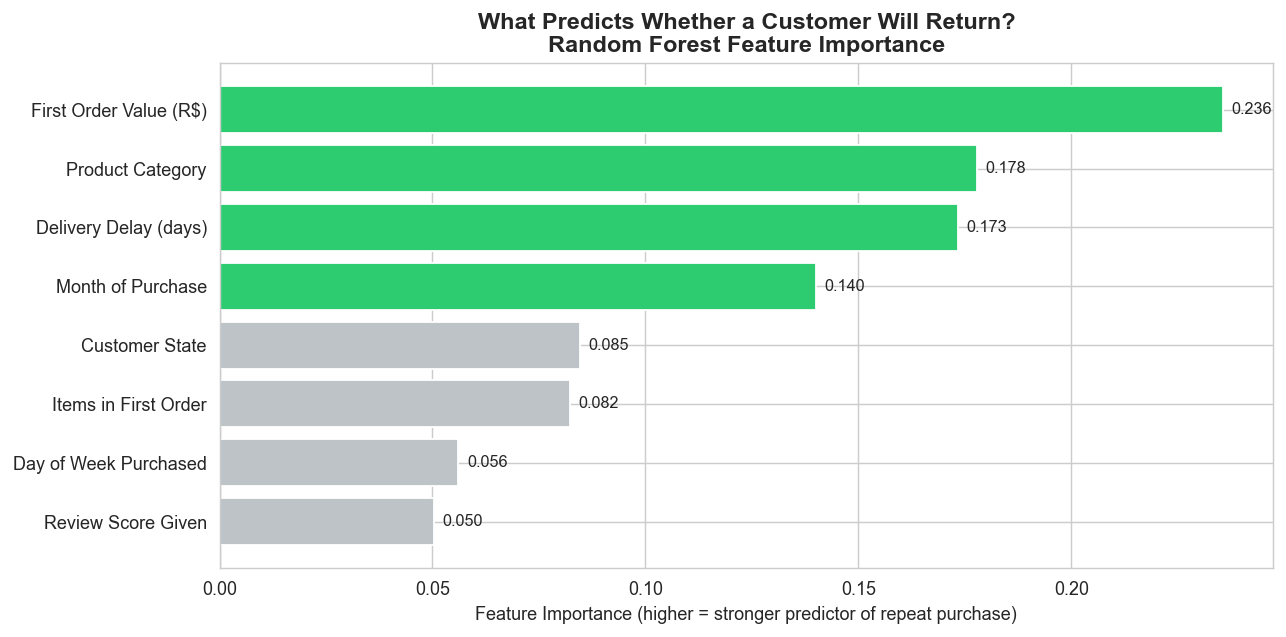

In [14]:
# Feature importance — the most business-valuable output of this model
feature_names = X.columns.tolist()
importances   = rf.feature_importances_

feat_df = (
    pd.DataFrame({'feature': feature_names, 'importance': importances})
    .sort_values('importance', ascending=True)
)

# Human-readable labels
label_map = {
    'total_order_value': 'First Order Value (R$)',
    'item_count': 'Items in First Order',
    'review_score': 'Review Score Given',
    'delivery_delay_days': 'Delivery Delay (days)',
    'purchase_dow': 'Day of Week Purchased',
    'purchase_month': 'Month of Purchase',
    'category_enc': 'Product Category',
    'customer_state_enc': 'Customer State'
}
feat_df['label'] = feat_df['feature'].map(label_map).fillna(feat_df['feature'])

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(feat_df['label'], feat_df['importance'],
               color=['#2ecc71' if i >= feat_df['importance'].median() else '#bdc3c7'
                      for i in feat_df['importance']])

ax.set_xlabel('Feature Importance (higher = stronger predictor of repeat purchase)', fontsize=10)
ax.set_title('What Predicts Whether a Customer Will Return?\nRandom Forest Feature Importance', 
             fontsize=13, fontweight='bold')

for bar, val in zip(bars, feat_df['importance']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../data/processed/feature_importance.png', bbox_inches='tight')
plt.show()

In [15]:
# Score ALL real customers with churn probability
X_all = model_df.drop(columns='is_repeat_customer')
model_df['churn_probability'] = rf.predict_proba(X_all)[:, 0]  # prob of NOT returning

# Export for Power BI
churn_output = model_df[['churn_probability', 'is_repeat_customer']].copy()
churn_output['customer_unique_id'] = first_orders['customer_unique_id'].values
churn_output.to_csv(PROCESSED / 'churn_scores.csv', index=False)

print('Churn scores exported.')
print(f"\nCustomers at high churn risk (>80%): {(churn_output['churn_probability'] > 0.8).sum():,}")
print(f"Customers at low churn risk (<30%):  {(churn_output['churn_probability'] < 0.3).sum():,}")

Churn scores exported.

Customers at high churn risk (>80%): 62
Customers at low churn risk (<30%):  37


---
## Summary of Findings

| Finding | Implication |
|---------|-------------|
| Only ~3% of customers ever return | Retention is a critical business problem |
| Month 1 retention is the sharpest drop | Re-engagement campaigns must fire within 30 days |
| Champions (<5% of customers) drive a disproportionate share of revenue | Protect this segment at all costs |
| Review score is a leading indicator of repeat purchase | Product quality and delivery experience directly drive LTV |
| First order value predicts return likelihood | Higher-basket customers are more likely to come back |

**Recommended actions:**
1. Launch a Day-7 / Day-30 re-engagement email sequence for all new customers
2. Prioritise fast delivery for Champions and Loyal segments
3. Use churn probability scores to rank customers for win-back campaigns
4. Investigate why certain product categories generate low review scores — fix the fulfilment issue before spending on acquisition